<a href="https://colab.research.google.com/github/Suryaprasadindra/warehouse-slotting-optimization/blob/main/warehouse_slotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)


In [11]:
# SKU master
np.random.seed(42)

num_skus = 300
sku_ids = [f"SKU-{i:04d}" for i in range(1, num_skus + 1)]

sku_master = pd.DataFrame({
    "sku_id": sku_ids,
    "description": [f"Product {i}" for i in range(1, num_skus + 1)],
    "case_size": np.random.randint(4, 24, num_skus),
    "pallet_size": np.random.randint(20, 80, num_skus),
    "zone": np.random.choice(["Ambient", "Chilled"], num_skus, p=[0.85, 0.15]),
    "heavy": np.random.rand(num_skus) < 0.2,
    "fragile": np.random.rand(num_skus) < 0.15,
    "oversized": np.random.rand(num_skus) < 0.1
})

sku_master.head()


,sku_id,description,case_size,pallet_size,zone,heavy,fragile,oversized
0,SKU-0001,Product 1,10,44,Ambient,False,False,False
1,SKU-0002,Product 2,23,61,Ambient,False,False,False
2,SKU-0003,Product 3,18,50,Chilled,False,True,False
3,SKU-0004,Product 4,14,73,Ambient,False,False,False
4,SKU-0005,Product 5,11,77,Ambient,False,False,False


In [12]:
# Demand history
dates = pd.date_range("2024-01-01", "2024-06-30", freq="D")

orders = []
for d in dates:
    num_orders = np.random.randint(40, 100)
    for _ in range(num_orders):
        sku = np.random.choice(sku_ids)
        qty = np.random.randint(1, 20)
        orders.append([f"ORD-{np.random.randint(100000, 999999)}", d, sku, qty])

demand_df = pd.DataFrame(orders, columns=["order_id", "order_date", "sku_id", "qty_picked"])
demand_df.head()


,order_id,order_date,sku_id,qty_picked
0,ORD-880641,2024-01-01,SKU-0209,3
1,ORD-756021,2024-01-01,SKU-0286,8
2,ORD-142828,2024-01-01,SKU-0300,4
3,ORD-125592,2024-01-01,SKU-0287,15
4,ORD-450877,2024-01-01,SKU-0208,10


In [13]:
# Warehouse locations
locations = []
for aisle in range(1, 21):
    for bay in range(1, 31):
        for level in range(1, 5):
            for pos in range(1, 3):
                loc_id = f"A{aisle:02d}-B{bay:02d}-L{level}-P{pos}"
                travel_score = aisle + bay * 0.1
                capacity = 80 if level == 1 else 40
                zone = "Chilled" if aisle <= 3 else "Ambient"
                locations.append([loc_id, aisle, bay, level, pos, travel_score, capacity, zone])

locations_df = pd.DataFrame(locations, columns=[
    "location_id", "aisle", "bay", "level", "position",
    "travel_score", "capacity", "zone"
])
locations_df.head()


,location_id,aisle,bay,level,position,travel_score,capacity,zone
0,A01-B01-L1-P1,1,1,1,1,1.1,80,Chilled
1,A01-B01-L1-P2,1,1,1,2,1.1,80,Chilled
2,A01-B01-L2-P1,1,1,2,1,1.1,40,Chilled
3,A01-B01-L2-P2,1,1,2,2,1.1,40,Chilled
4,A01-B01-L3-P1,1,1,3,1,1.1,40,Chilled


In [14]:
# Aggregate daily demand per SKU
daily_demand = (
    demand_df.groupby(["order_date", "sku_id"])["qty_picked"]
    .sum()
    .reset_index()
)

daily_demand.head()


,order_date,sku_id,qty_picked
0,2024-01-01,SKU-0005,27
1,2024-01-01,SKU-0012,28
2,2024-01-01,SKU-0014,9
3,2024-01-01,SKU-0020,18
4,2024-01-01,SKU-0021,10


In [15]:
# 7-day rolling demand per SKU
daily_demand["rolling_7d"] = (
    daily_demand.groupby("sku_id")["qty_picked"]
    .rolling(7, min_periods=1)
    .mean()
    .reset_index(drop=True)
)

daily_demand.head()


,order_date,sku_id,qty_picked,rolling_7d
0,2024-01-01,SKU-0005,27,8.000000
1,2024-01-01,SKU-0012,28,9.000000
2,2024-01-01,SKU-0014,9,6.666667
3,2024-01-01,SKU-0020,18,9.250000
4,2024-01-01,SKU-0021,10,7.800000


In [16]:
# Total demand per SKU
sku_totals = (
    daily_demand.groupby("sku_id")["qty_picked"]
    .sum()
    .reset_index()
    .rename(columns={"qty_picked": "total_picks"})
)

sku_totals = sku_totals.sort_values("total_picks", ascending=False)
sku_totals["cum_pct"] = sku_totals["total_picks"].cumsum() / sku_totals["total_picks"].sum()

def classify_abc(p):
    if p <= 0.2:
        return "A"
    elif p <= 0.5:
        return "B"
    else:
        return "C"

sku_totals["velocity_class"] = sku_totals["cum_pct"].apply(classify_abc)
sku_totals.head()


,sku_id,total_picks,cum_pct,velocity_class
9,SKU-0010,642,0.004942,A
145,SKU-0146,636,0.009837,A
15,SKU-0016,620,0.014610,A
127,SKU-0128,607,0.019282,A
282,SKU-0283,606,0.023946,A


In [17]:
# Merge into SKU master
sku_master = sku_master.merge(
    sku_totals[["sku_id", "total_picks", "velocity_class"]],
    on="sku_id", how="left"
)

sku_master["total_picks"] = sku_master["total_picks"].fillna(0)
sku_master["velocity_class"] = sku_master["velocity_class"].fillna("C")

sku_master.head()


,sku_id,description,case_size,pallet_size,zone,heavy,fragile,oversized,total_picks,velocity_class
0,SKU-0001,Product 1,10,44,Ambient,False,False,False,313,C
1,SKU-0002,Product 2,23,61,Ambient,False,False,False,423,C
2,SKU-0003,Product 3,18,50,Chilled,False,True,False,360,C
3,SKU-0004,Product 4,14,73,Ambient,False,False,False,346,C
4,SKU-0005,Product 5,11,77,Ambient,False,False,False,517,A


In [18]:
velocity_map = {"A": 3, "B": 2, "C": 1}
sku_master["velocity_score"] = sku_master["velocity_class"].map(velocity_map)
sku_master["cube"] = sku_master["case_size"] * sku_master["pallet_size"]

sku_master["norm_picks"] = sku_master["total_picks"] / sku_master["total_picks"].max()
sku_master["norm_velocity"] = sku_master["velocity_score"] / 3
sku_master["norm_cube"] = 1 - (sku_master["cube"] / sku_master["cube"].max())

sku_master["slotting_score"] = (
    0.5 * sku_master["norm_picks"] +
    0.3 * sku_master["norm_velocity"] +
    0.2 * sku_master["norm_cube"]
)

sku_master[["sku_id", "velocity_class", "slotting_score"]].head()


,sku_id,velocity_class,slotting_score
0,SKU-0001,C,0.493426
1,SKU-0002,C,0.468913
2,SKU-0003,C,0.477399
3,SKU-0004,C,0.452537
4,SKU-0005,A,0.805737


In [19]:
locations_df["norm_travel"] = 1 - (locations_df["travel_score"] / locations_df["travel_score"].max())
locations_df["level_score"] = 1 - ((locations_df["level"] - 1) / 3)

locations_df["location_score"] = (
    0.6 * locations_df["norm_travel"] +
    0.4 * locations_df["level_score"]
)

locations_df[["location_id", "location_score"]].head()


,location_id,location_score
0,A01-B01-L1-P1,0.971304
1,A01-B01-L1-P2,0.971304
2,A01-B01-L2-P1,0.837971
3,A01-B01-L2-P2,0.837971
4,A01-B01-L3-P1,0.704638


In [20]:
recent = (
    daily_demand
    .groupby("sku_id")
    .apply(lambda x: x["rolling_7d"].tail(7).mean())
    .reset_index(name="recent_7d")
)


/tmp/ipykernel_1200/2228301920.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["rolling_7d"].tail(7).mean())


In [21]:
past = (
    daily_demand
    .groupby("sku_id")
    .apply(lambda x: x["rolling_7d"].shift(7).tail(7).mean())
    .reset_index(name="past_7d")
)


/tmp/ipykernel_1200/3690836704.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["rolling_7d"].shift(7).tail(7).mean())


In [22]:
velocity_change = recent.merge(past, on="sku_id", how="left")
velocity_change["past_7d"] = velocity_change["past_7d"].fillna(0)
velocity_change["change"] = velocity_change["recent_7d"] - velocity_change["past_7d"]

velocity_change.head()


,sku_id,recent_7d,past_7d,change
0,SKU-0001,10.605442,12.000000,-1.394558
1,SKU-0002,11.673469,9.918367,1.755102
2,SKU-0003,10.673469,12.901361,-2.227891
3,SKU-0004,11.591837,9.496599,2.095238
4,SKU-0005,11.306122,11.374150,-0.068027


In [23]:
sku_master = sku_master.merge(velocity_change, on="sku_id", how="left")
sku_master["change"] = sku_master["change"].fillna(0)


In [24]:
threshold = sku_master["change"].abs().quantile(0.8)
sku_master["needs_reslot"] = sku_master["change"].abs() > threshold

sku_master[["sku_id", "change", "needs_reslot"]].head()


,sku_id,change,needs_reslot
0,SKU-0001,-1.394558,False
1,SKU-0002,1.755102,False
2,SKU-0003,-2.227891,True
3,SKU-0004,2.095238,True
4,SKU-0005,-0.068027,False


In [25]:
sorted_skus = sku_master.sort_values("slotting_score", ascending=False).reset_index(drop=True)
sorted_locs = locations_df.sort_values("location_score", ascending=False).reset_index(drop=True)


In [26]:
assignments = []
loc_idx = 0

for i, row in sorted_skus.iterrows():
    sku_zone = row["zone"]

    # find next location with same zone
    while loc_idx < len(sorted_locs):
        loc = sorted_locs.iloc[loc_idx]
        loc_idx += 1

        if loc["zone"] == sku_zone:
            assignments.append([
                row["sku_id"],
                row["slotting_score"],
                sku_zone,
                loc["location_id"],
                loc["location_score"],
                row["needs_reslot"]
            ])
            break


In [27]:
slotting_map = pd.DataFrame(assignments, columns=[
    "sku_id", "slotting_score", "sku_zone",
    "location_id", "location_score", "needs_reslot"
])

slotting_map.head(10)


,sku_id,slotting_score,sku_zone,location_id,location_score,needs_reslot
0,SKU-0016,0.956550,Chilled,A01-B01-L1-P1,0.971304,False
1,SKU-0146,0.951391,Ambient,A04-B01-L1-P1,0.893043,False
2,SKU-0111,0.944952,Ambient,A04-B01-L1-P2,0.893043,False
3,SKU-0010,0.944737,Ambient,A04-B02-L1-P1,0.890435,False
4,SKU-0128,0.931552,Ambient,A04-B02-L1-P2,0.890435,False
5,SKU-0258,0.924246,Ambient,A04-B03-L1-P2,0.887826,False
6,SKU-0283,0.923908,Ambient,A04-B03-L1-P1,0.887826,False
7,SKU-0095,0.902872,Ambient,A04-B04-L1-P1,0.885217,False
8,SKU-0052,0.902675,Ambient,A04-B04-L1-P2,0.885217,False
9,SKU-0112,0.901162,Ambient,A04-B05-L1-P1,0.882609,True


In [28]:
move_list = slotting_map[slotting_map["needs_reslot"] == True]
move_list.head(10)


,sku_id,slotting_score,sku_zone,location_id,location_score,needs_reslot
9,SKU-0112,0.901162,Ambient,A04-B05-L1-P1,0.882609,True
13,SKU-0296,0.887609,Ambient,A04-B07-L1-P2,0.877391,True
27,SKU-0021,0.861620,Chilled,A03-B22-L1-P2,0.864348,True
32,SKU-0065,0.844816,Ambient,A05-B03-L1-P1,0.861739,True
34,SKU-0083,0.836186,Ambient,A05-B04-L1-P1,0.859130,True
35,SKU-0280,0.833396,Ambient,A05-B04-L1-P2,0.859130,True
39,SKU-0150,0.829484,Ambient,A04-B15-L1-P1,0.856522,True
44,SKU-0214,0.800423,Ambient,A04-B16-L1-P2,0.853913,True
56,SKU-0179,0.751175,Ambient,A05-B09-L1-P2,0.846087,True
61,SKU-0031,0.742594,Ambient,A05-B10-L1-P1,0.843478,True


In [29]:
move_list.shape[0]


60

In [30]:
# Top 10% best locations
top_n = int(len(locations_df) * 0.10)
top_locations = locations_df.sort_values("location_score", ascending=False).head(top_n)

top_loc_ids = set(top_locations["location_id"])

# Merge slotting map with SKU velocity class
merged = slotting_map.merge(
    sku_master[["sku_id", "velocity_class"]],
    on="sku_id", how="left"
)

a_skus = merged[merged["velocity_class"] == "A"]
a_in_top = a_skus[a_skus["location_id"].isin(top_loc_ids)]

kpi_a_in_top = len(a_in_top) / len(a_skus)
kpi_a_in_top


1.0

In [31]:
# Baseline: random assignment
baseline = slotting_map.copy()
baseline["baseline_location"] = np.random.choice(
    locations_df["location_id"], size=len(baseline)
)

baseline = baseline.merge(
    locations_df[["location_id", "travel_score"]],
    left_on="baseline_location", right_on="location_id",
    how="left"
).rename(columns={"travel_score": "baseline_travel"})

# Optimized travel score
optimized = slotting_map.merge(
    locations_df[["location_id", "travel_score"]],
    on="location_id", how="left"
).rename(columns={"travel_score": "optimized_travel"})

# Combine
travel_compare = baseline.merge(
    optimized[["sku_id", "optimized_travel"]],
    on="sku_id", how="left"
)

travel_reduction = (
    travel_compare["baseline_travel"].mean() -
    travel_compare["optimized_travel"].mean()
)

travel_reduction


np.float64(5.301666666666665)

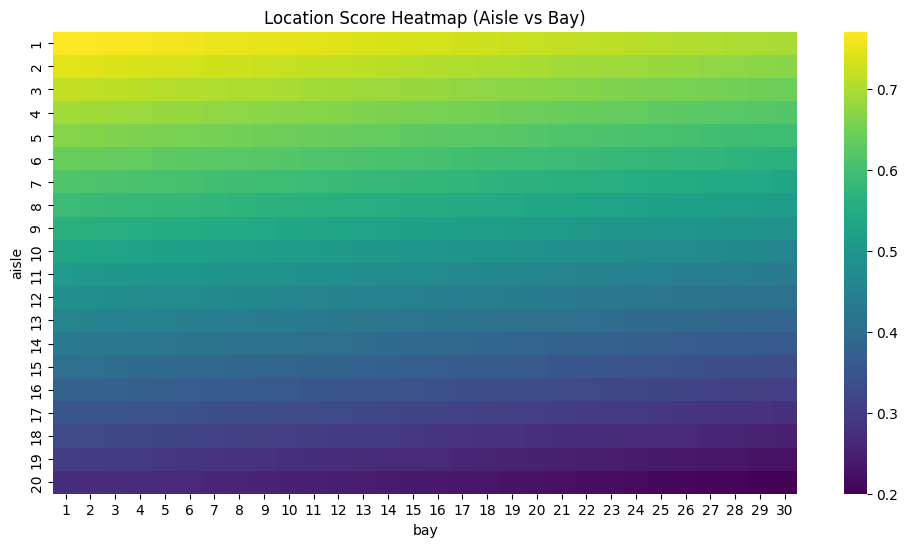

In [32]:
heat = locations_df.pivot_table(
    index="aisle", columns="bay", values="location_score", aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(heat, cmap="viridis")
plt.title("Location Score Heatmap (Aisle vs Bay)")
plt.show()


/tmp/ipykernel_1200/1415686975.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x="sku_id", y="slotting_score", palette="Blues_r")


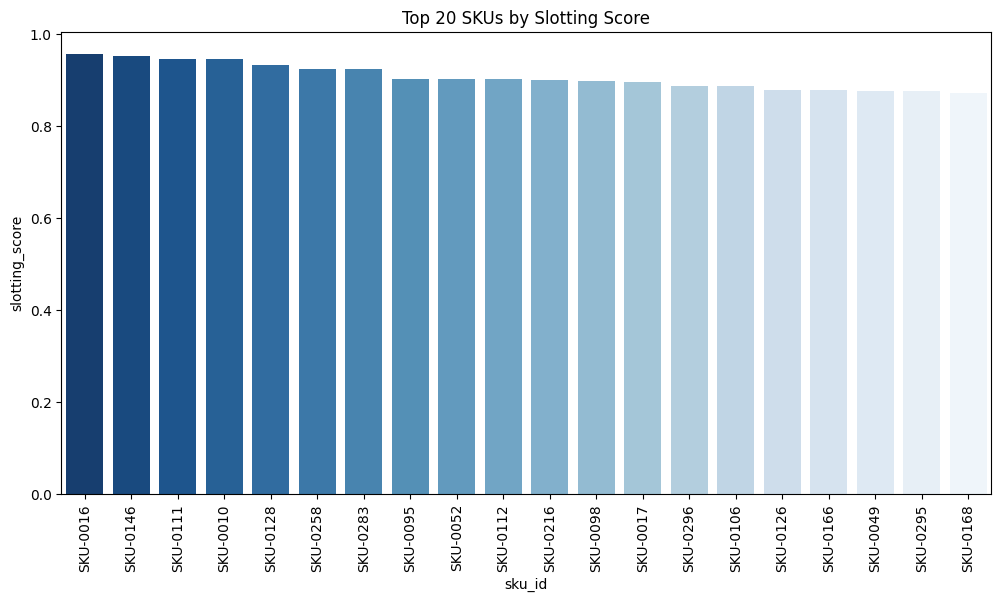

In [33]:
top20 = slotting_map.sort_values("slotting_score", ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x="sku_id", y="slotting_score", palette="Blues_r")
plt.xticks(rotation=90)
plt.title("Top 20 SKUs by Slotting Score")
plt.show()


In [34]:
sample_skus = sku_master["sku_id"].sample(3).tolist()
sample_skus


['SKU-0197', 'SKU-0274', 'SKU-0235']

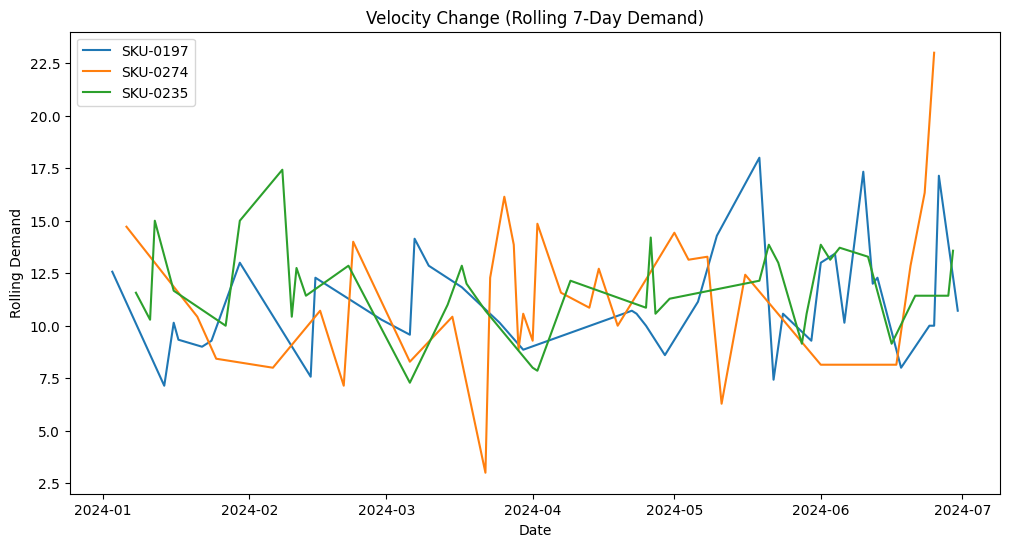

In [35]:
plt.figure(figsize=(12, 6))

for sku in sample_skus:
    subset = daily_demand[daily_demand["sku_id"] == sku]
    plt.plot(subset["order_date"], subset["rolling_7d"], label=sku)

plt.legend()
plt.title("Velocity Change (Rolling 7-Day Demand)")
plt.xlabel("Date")
plt.ylabel("Rolling Demand")
plt.show()


In [36]:
move_list_summary = move_list.merge(
    sku_master[["sku_id", "velocity_class", "change"]],
    on="sku_id", how="left"
)

move_list_summary.head()


,sku_id,slotting_score,sku_zone,location_id,location_score,needs_reslot,velocity_class,change
0,SKU-0112,0.901162,Ambient,A04-B05-L1-P1,0.882609,True,A,-2.862245
1,SKU-0296,0.887609,Ambient,A04-B07-L1-P2,0.877391,True,A,1.990816
2,SKU-0021,0.861620,Chilled,A03-B22-L1-P2,0.864348,True,A,3.426531
3,SKU-0065,0.844816,Ambient,A05-B03-L1-P1,0.861739,True,A,3.387755
4,SKU-0083,0.836186,Ambient,A05-B04-L1-P1,0.859130,True,A,3.186395


In [37]:
move_list_summary.shape[0]


60

In [38]:
print("📌 KPI Summary")
print("------------------------------")
print(f"A-class SKUs in top 10% locations: {kpi_a_in_top:.2%}")
print(f"Average travel score reduction: {travel_reduction:.2f}")
print(f"SKUs flagged for re-slotting: {move_list_summary.shape[0]}")


📌 KPI Summary
------------------------------
A-class SKUs in top 10% locations: 100.00%
Average travel score reduction: 5.30
SKUs flagged for re-slotting: 60


In [39]:
import plotly.graph_objects as go

fig_kpi = go.Figure()

fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=kpi_a_in_top * 100,
    title={"text": "A‑Class in Top Locations (%)"},
    domain={"row": 0, "column": 0}
))

fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=travel_reduction,
    title={"text": "Travel Score Reduction"},
    domain={"row": 0, "column": 1}
))

fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=move_list_summary.shape[0],
    title={"text": "SKUs Needing Re‑Slotting"},
    domain={"row": 0, "column": 2}
))

fig_kpi.update_layout(
    grid={"rows": 1, "columns": 3},
    height=300,
    title="Warehouse Slotting KPIs"
)

fig_kpi.show()


In [40]:
import plotly.express as px

heat = locations_df.pivot_table(
    index="aisle", columns="bay", values="location_score", aggfunc="mean"
)

fig_heat = px.imshow(
    heat,
    aspect="auto",
    color_continuous_scale="Viridis",
    title="Location Score Heatmap (Aisle × Bay)"
)

fig_heat.show()


In [41]:
top20 = slotting_map.sort_values("slotting_score", ascending=False).head(20)

fig_top20 = px.bar(
    top20,
    x="sku_id",
    y="slotting_score",
    title="Top 20 SKUs by Slotting Score",
    color="slotting_score",
    color_continuous_scale="Blues"
)

fig_top20.update_layout(xaxis_tickangle=90)
fig_top20.show()


In [42]:
sample_skus = sku_master["sku_id"].sample(3).tolist()

fig_velocity = go.Figure()

for sku in sample_skus:
    subset = daily_demand[daily_demand["sku_id"] == sku]
    fig_velocity.add_trace(go.Scatter(
        x=subset["order_date"],
        y=subset["rolling_7d"],
        mode="lines",
        name=sku
    ))

fig_velocity.update_layout(
    title="Velocity Trend (Rolling 7‑Day Demand)",
    xaxis_title="Date",
    yaxis_title="Rolling Demand"
)

fig_velocity.show()


In [43]:
import pandas as pd

move_list_summary.head(5)


,sku_id,slotting_score,sku_zone,location_id,location_score,needs_reslot,velocity_class,change
0,SKU-0112,0.901162,Ambient,A04-B05-L1-P1,0.882609,True,A,-2.862245
1,SKU-0296,0.887609,Ambient,A04-B07-L1-P2,0.877391,True,A,1.990816
2,SKU-0021,0.861620,Chilled,A03-B22-L1-P2,0.864348,True,A,3.426531
3,SKU-0065,0.844816,Ambient,A05-B03-L1-P1,0.861739,True,A,3.387755
4,SKU-0083,0.836186,Ambient,A05-B04-L1-P1,0.859130,True,A,3.186395


In [44]:
import plotly.figure_factory as ff

fig_table = ff.create_table(move_list_summary.head(20))
fig_table.show()


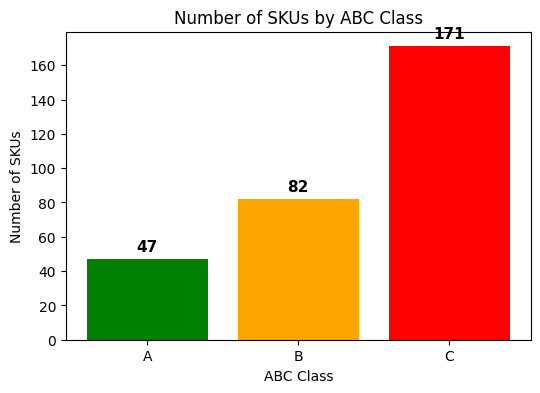

In [53]:
import matplotlib.pyplot as plt

# assuming sku_master has column 'velocity_class' with values 'A', 'B', 'C'
abc_counts = sku_master['velocity_class'].value_counts().reindex(['A', 'B', 'C'])

plt.figure(figsize=(6, 4))
bars = plt.bar(abc_counts.index, abc_counts.values, color=['green', 'orange', 'red'])
plt.title("Number of SKUs by ABC Class")
plt.xlabel("ABC Class")
plt.ylabel("Number of SKUs")

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 3, f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()


In [48]:
daily_demand.columns


Index(['order_date', 'sku_id', 'qty_picked', 'rolling_7d'], dtype='object')

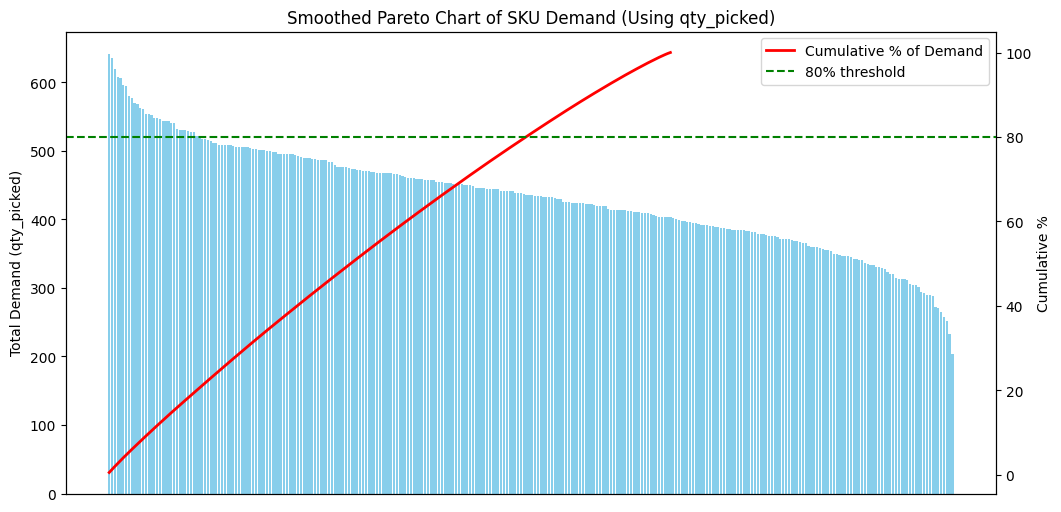

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Calculate total demand per SKU
demand_per_sku = daily_demand.groupby('sku_id')['qty_picked'].sum().reset_index()

# Step 2: Sort SKUs by demand (descending)
demand_per_sku = demand_per_sku.sort_values('qty_picked', ascending=False)

# Step 3: Calculate cumulative percentage
demand_per_sku['cum_pct'] = (
    demand_per_sku['qty_picked'].cumsum() / demand_per_sku['qty_picked'].sum() * 100
)

# Step 4: Smooth the cumulative line (reduce points)
smooth_x = np.linspace(0, len(demand_per_sku)-1, 200)
smooth_y = np.interp(smooth_x, np.arange(len(demand_per_sku)), demand_per_sku['cum_pct'])

# Step 5: Plot Pareto chart
plt.figure(figsize=(12, 6))
plt.bar(demand_per_sku['sku_id'], demand_per_sku['qty_picked'], color='skyblue', label='SKU Demand')
plt.xticks([], [])
plt.ylabel("Total Demand (qty_picked)")

# Smooth cumulative line
plt.twinx()
plt.plot(smooth_y, color='red', linewidth=2, label='Cumulative % of Demand')
plt.ylabel("Cumulative %")
plt.axhline(80, color='green', linestyle='--', label='80% threshold')

plt.title("Smoothed Pareto Chart of SKU Demand (Using qty_picked)")
plt.legend(loc="best")
plt.show()
